In [6]:

import subprocess, sys

packages = [
    "requests", "beautifulsoup4", "lxml", "lxml_html_clean",
    "pandas", "matplotlib", "seaborn",
    "trafilatura",
    "duckduckgo-search", "tqdm", "nltk",
    "feedparser",          
    "deep-translator",    
    "urllib3",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print(" All packages installed.")

 All packages installed.


In [7]:
import requests
from bs4 import BeautifulSoup
import trafilatura
import feedparser
from duckduckgo_search import DDGS
from deep_translator import GoogleTranslator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, time, warnings, urllib.parse
from tqdm import tqdm
import nltk
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" Imports complete.")

 Imports complete.


In [9]:

SEARCH_QUERIES_EN = {
    "Yanbu_Transit": [
        "Yanbu crude oil tanker Asia transit time days",
        "Saudi Arabia Red Sea Yanbu shipping route Asia Pacific voyage duration",
        "Yanbu export terminal shipping time versus Ras Tanura Asia",
        "Red Sea crude oil tanker route days China Japan Korea",
        "Saudi oil diversification Yanbu Red Sea route longer transit",
    ],
    "Yanbu_Cost": [
        "Yanbu crude oil freight cost per barrel Asia shipping premium",
        "Saudi Arabia Red Sea export freight differential cost analysis",
        "Yanbu route economics cost competitiveness Asian refiners",
        "Red Sea crude oil tanker freight rate Suez Canal cost",
        "Saudi crude oil export cost Red Sea versus Gulf route",
    ],
    "Americas_Cape_Transit": [
        "US Gulf Coast crude oil Asia transit days Cape of Good Hope",
        "American crude export Asia tanker voyage weeks long haul",
        "USGC crude oil Cape route shipping duration Asia Pacific",
        "WTI crude export Asia shipping time 45 days 60 days",
        "US crude oil tanker Asia route how many days",
    ],
    "Americas_Cape_Cost": [
        "US crude oil export freight cost Asia Cape of Good Hope premium",
        "American crude oil shipping cost Asia versus Middle East barrels",
        "USGC crude freight rate Asia competitiveness discount per barrel",
        "WTI crude export Asia cost economics 2023 2024",
        "US crude Asia long haul freight cost disadvantage",
    ],
}


SEARCH_QUERIES_JA = {
    "Yanbu_Transit_JA": [
        "ヤンブー 原油 アジア 輸送日数 タンカー 航路",           
        "サウジアラビア 紅海 原油 輸出 アジア 所要日数",        
        "ヤンブー港 原油 タンカー 輸送時間 日本 中国",            
    ],
    "Yanbu_Cost_JA": [
        "ヤンブー 原油 輸送コスト アジア 運賃",                  
        "紅海 原油 輸出 スエズ運河 コスト 割増",               
        "サウジアラビア 多角化 原油輸出 コスト 分析",            
    ],
    "Americas_Cape_Transit_JA": [
        "米国 原油 アジア 輸送 喜望峰 所要日数",                  
        "アメリカ産原油 アジア タンカー 航路 日数 週数",      
        "WTI 原油 輸出 アジア 輸送時間 長距離",                  
    ],
    "Americas_Cape_Cost_JA": [
        "米国産原油 アジア 輸送コスト 喜望峰 割増料金",           
        "アメリカ 原油 アジア 運賃 中東産 比較 コスト",    
        "USGC 原油 アジア 競争力 割引 バレル",                   
    ],
}

TIME_KEYWORDS = [
    "days", "weeks", "transit", "voyage", "journey", "longer", "shorter",
    "duration", "sailing", "haul", "leg", "route", "distance"
]
COST_KEYWORDS = [
    "cost", "freight", "rate", "premium", "dollar", "$/bbl", "per barrel",
    "expensive", "cheaper", "savings", "discount", "tariff", "fee", "toll",
    "economics", "competitive", "surcharge", "differential"
]
RELEVANCE_KEYS = TIME_KEYWORDS + COST_KEYWORDS

total_q = sum(len(v) for v in SEARCH_QUERIES_EN.values()) + sum(len(v) for v in SEARCH_QUERIES_JA.values())
print(f" {total_q} total queries configured ({sum(len(v) for v in SEARCH_QUERIES_EN.values())} English, {sum(len(v) for v in SEARCH_QUERIES_JA.values())} Japanese)")

 32 total queries configured (20 English, 12 Japanese)


In [ ]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

def search_ddg(query: str, max_results: int = 8) -> list[dict]:
    results = []
    try:
        with DDGS() as ddgs:
            for r in ddgs.text(query, max_results=max_results):
                results.append({
                    "title":   r.get("title", ""),
                    "url":     r.get("href", ""),
                    "snippet": r.get("body", ""),
                    "source_type": "duckduckgo",
                })
    except Exception as e:
        print(f"  ⚠️  DDG error: {e}")
    return results

def search_google_news(query: str, lang: str = "en", country: str = "US") -> list[dict]:
    """
    Uses Google News RSS (no API key needed).
    lang/country: 'en'/'US' for English, 'ja'/'JP' for Japanese.
    """
    encoded = urllib.parse.quote(query)
    url = (
        f"https://news.google.com/rss/search?"
        f"q={encoded}&hl={lang}&gl={country}&ceid={country}:{lang}"
    )
    results = []
    try:
        feed = feedparser.parse(url)
        for entry in feed.entries[:8]:
            results.append({
                "title":   entry.get("title", ""),
                "url":     entry.get("link", ""),
                "snippet": BeautifulSoup(entry.get("summary", ""), "lxml").get_text(" "),
                "source_type": f"google_news_{lang}",
            })
    except Exception as e:
        print(f" Google News RSS error: {e}")
    return results

INDUSTRY_SITES = [
    "site:reuters.com",
    "site:bloomberg.com",
    "site:spglobal.com",
    "site:oilprice.com",
    "site:energyintel.com",
    "site:offshore-energy.biz",
    "site:hellenicshippingnews.com",
    "site:tradewindsnews.com",
    "site:argusmedia.com",
]

JA_SITES = [
    "site:nikkei.com",
    "site:jiji.com",
    "site:mainichi.jp",
    "site:yomiuri.co.jp",
    "site:enecho.meti.go.jp",   
    "site:iea.org",
    "site:jogmec.go.jp",       
]

def search_site(query: str, site_operator: str, max_results: int = 4) -> list[dict]:
    return search_ddg(f"{site_operator} {query}", max_results=max_results)


def fetch_article_text(url: str, timeout: int = 15) -> str:
    """Fetch full article text using trafilatura; fallback to BeautifulSoup."""
    try:
        downloaded = trafilatura.fetch_url(url)
        if downloaded:
            text = trafilatura.extract(
                downloaded,
                include_comments=False,
                include_tables=True,
                no_fallback=False,
            )
            if text and len(text) > 200:
                return text
    except Exception:
        pass
    try:
        resp = requests.get(url, headers=HEADERS, timeout=timeout)
        soup = BeautifulSoup(resp.text, "lxml")
        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()
        return " ".join(soup.get_text(" ", strip=True).split())
    except Exception:
        return ""


def translate_ja_to_en(text: str) -> str:
    """Translate Japanese text to English in chunks (GoogleTranslator limit: 5000 chars)."""
    if not text or not text.strip():
        return ""
    try:
        chunks = [text[i:i+4500] for i in range(0, len(text), 4500)]
        translated = []
        for chunk in chunks[:4]:  # max 4 chunks per article
            t = GoogleTranslator(source='ja', target='en').translate(chunk)
            if t:
                translated.append(t)
            time.sleep(0.3)
        return " ".join(translated)
    except Exception:
        return ""

def extract_relevant_sentences(text: str, keywords: list[str], window: int = 2) -> list[str]:
    """
    Split text into sentences; return those hitting any keyword + their neighbours.
    Min length 50 chars to filter noise.
    """
    from nltk.tokenize import sent_tokenize
    sentences = sent_tokenize(text)
    relevant_idx = set()
    kw_lower = [k.lower() for k in keywords]
    for i, sent in enumerate(sentences):
        if any(k in sent.lower() for k in kw_lower):
            for j in range(max(0, i - window), min(len(sentences), i + window + 1)):
                relevant_idx.add(j)
    return [sentences[i] for i in sorted(relevant_idx) if len(sentences[i]) > 50]


print(" Multi-source scraping engine ready (DDG + Google News RSS + Industry sites + Japanese).")

 Multi-source scraping engine ready (DDG + Google News RSS + Industry sites + Japanese).


In [11]:
collected_quotes = []   
seen_urls = set()      

def ingest_results(results, route, aspect, lang="en"):
    """Fetch articles from a list of search results and store relevant sentences."""
    kw_list = TIME_KEYWORDS if aspect == "Transit" else COST_KEYWORDS
    for res in results:
        url = res.get("url", "")
        if not url or url in seen_urls or not url.startswith("http"):
            continue
        seen_urls.add(url)

        snippet_text = res.get("snippet", "")
        if lang == "ja" and snippet_text:
            snippet_text = translate_ja_to_en(snippet_text)
    
        full_text = fetch_article_text(url)
        if lang == "ja" and full_text:
            full_text = translate_ja_to_en(full_text)
        time.sleep(0.6)

        best_text = full_text if len(full_text) > len(snippet_text) else snippet_text
        if not best_text.strip():
            continue

        sentences = extract_relevant_sentences(best_text, RELEVANCE_KEYS, window=1)
        for sent in sentences:
            collected_quotes.append({
                "route":       route,
                "aspect":      aspect,
                "lang":        lang,
                "source_type": res.get("source_type", "unknown"),
                "source":      res.get("title", "")[:120],
                "url":         url,
                "quote":       sent.strip(),
                "char_len":    len(sent),
            })

print("\n━━━ PHASE 1: English sources (DDG + Google News RSS) ━━━")
for category, queries in SEARCH_QUERIES_EN.items():
    route  = "Yanbu" if category.startswith("Yanbu") else "Americas_Cape"
    aspect = "Transit" if "Transit" in category else "Cost"
    print(f"\n🔍 {category}")
    for query in tqdm(queries, desc=f"  Queries", leave=False):
        # DuckDuckGo
        ddg_res = search_ddg(query, max_results=8)
        ingest_results(ddg_res, route, aspect, lang="en")
        time.sleep(1.2)
        # Google News RSS
        gnews_res = search_google_news(query, lang="en", country="US")
        ingest_results(gnews_res, route, aspect, lang="en")
        time.sleep(0.8)

print(f"\n  → {len(collected_quotes)} quotes so far from {len(seen_urls)} URLs")

print("\n━━━ PHASE 2: Industry site searches ━━━")
SITE_QUERIES = [
    ("Yanbu",        "Transit", "Yanbu crude oil Asia tanker days transit"),
    ("Yanbu",        "Cost",    "Yanbu crude freight cost Asia per barrel"),
    ("Americas_Cape","Transit", "US Gulf crude Asia Cape Good Hope voyage days"),
    ("Americas_Cape","Cost",    "USGC crude oil Asia freight cost discount"),
]
for route, aspect, query in tqdm(SITE_QUERIES, desc="  Site queries"):
    for site in INDUSTRY_SITES:
        res = search_site(query, site, max_results=3)
        ingest_results(res, route, aspect, lang="en")
        time.sleep(1.0)

print(f"  → {len(collected_quotes)} quotes so far from {len(seen_urls)} URLs")

print("\n━━━ PHASE 3: Japanese sources (Google News JP + DDG + JP sites) ━━━")
for category, queries in SEARCH_QUERIES_JA.items():
    base = category.replace("_JA", "")
    route  = "Yanbu" if base.startswith("Yanbu") else "Americas_Cape"
    aspect = "Transit" if "Transit" in base else "Cost"
    print(f"\n🔍 {category}")
    for query in tqdm(queries, desc="  JP Queries", leave=False):
        # Google News Japan RSS
        gnews_jp = search_google_news(query, lang="ja", country="JP")
        ingest_results(gnews_jp, route, aspect, lang="ja")
        time.sleep(1.0)
        # DDG Japanese
        ddg_jp = search_ddg(query, max_results=5)
        ingest_results(ddg_jp, route, aspect, lang="ja")
        time.sleep(1.2)
    # Also try English queries on JP industry sites
    en_q_map = {
        "Yanbu_Transit":        "Yanbu crude oil tanker Asia transit days",
        "Yanbu_Cost":           "Yanbu crude freight cost Asia",
        "Americas_Cape_Transit":"US crude Cape Good Hope Asia days",
        "Americas_Cape_Cost":   "US crude Asia freight cost",
    }
    en_q = en_q_map.get(base, "")
    if en_q:
        for jp_site in JA_SITES:
            res = search_site(en_q, jp_site, max_results=3)
            ingest_results(res, route, aspect, lang="en")
            time.sleep(0.8)

print(f"\n All phases complete.")
print(f"   Total raw quote candidates : {len(collected_quotes)}")
print(f"   Unique URLs scraped        : {len(seen_urls)}")


━━━ PHASE 1: English sources (DDG + Google News RSS) ━━━

🔍 Yanbu_Transit


  Queries:   0%|          | 0/5 [00:00<?, ?it/s]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  20%|██        | 1/5 [00:17<01:08, 17.10s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  40%|████      | 2/5 [00:34<00:52, 17.37s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  60%|██████    | 3/5 [00:52<00:34, 17.38s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`)


🔍 Yanbu_Cost


  Queries:   0%|          | 0/5 [00:00<?, ?it/s]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  20%|██        | 1/5 [00:15<01:01, 15.34s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  40%|████      | 2/5 [00:33<00:50, 16.88s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  Queries:  60%|██████    | 3/5 [00:47<00:31, 15.55s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`)


🔍 Americas_Cape_Transit


...


🔍 Americas_Cape_Transit_JA


  JP Queries:   0%|          | 0/3 [00:00<?, ?it/s]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  JP Queries:  33%|███▎      | 1/3 [00:26<00:53, 26.54s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  JP Queries:  67%|██████▋   | 2/3 [00:29<00:12, 12.80s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install d


🔍 Americas_Cape_Cost_JA


  JP Queries:   0%|          | 0/3 [00:00<?, ?it/s]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  JP Queries:  33%|███▎      | 1/3 [00:08<00:16,  8.31s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
  JP Queries:  67%|██████▋   | 2/3 [00:29<00:15, 15.99s/it]/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/var/folders/nr/2xfdpm3n0sd455zcnlb_77m40000gn/T/ipykernel_77229/1870634625.py:13: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install d


 All phases complete.
   Total raw quote candidates : 1224
   Unique URLs scraped        : 241


In [12]:
df = pd.DataFrame(collected_quotes)

if df.empty:
    print("  No quotes collected — check network access or try again.")
else:
    
    df["quote_key"] = df["quote"].str[:120].str.lower().str.strip()
    df = df.drop_duplicates(subset="quote_key").drop(columns="quote_key")

    strong_signals = [
        "days", "weeks", "cost", "freight", "$/", "per barrel",
        "longer", "shorter", "premium", "cheaper", "transit", "voyage",
        "haul", "rate", "discount", "competitive", "surcharge"
    ]
    mask = (
        df["quote"].str.lower().apply(lambda q: any(s in q for s in strong_signals))
        & (df["char_len"] >= 60)
    )
    df_clean = df[mask].copy().reset_index(drop=True)

    print(f" After cleaning: {len(df_clean)} high-quality quotes retained.")
    print(f"\n Breakdown by route and aspect:")
    print(df_clean.groupby(["route", "aspect"]).size().to_string())
    print(f"\n Breakdown by language:")
    print(df_clean["lang"].value_counts().to_string())
    print(f"\n Breakdown by source type:")
    print(df_clean["source_type"].value_counts().to_string())

 After cleaning: 502 high-quality quotes retained.

 Breakdown by route and aspect:
route          aspect 
Americas_Cape  Cost       173
               Transit     43
Yanbu          Cost        78
               Transit    208

 Breakdown by language:
lang
en    477
ja     25

 Breakdown by source type:
source_type
duckduckgo        462
google_news_en     28
google_news_ja     12


In [13]:
def print_quotes(df_in, route, aspect, max_quotes=10):
    sub = df_in[(df_in["route"] == route) & (df_in["aspect"] == aspect)].head(max_quotes)
    label = "Transit Time" if aspect == "Transit" else "Shipping Cost"
    display(Markdown(f"{route.replace('_',' ')} — {label} ({len(sub)} quotes)"))
    if sub.empty:
        display(Markdown("_No relevant quotes found for this category._"))
        return
    for idx, (_, row) in enumerate(sub.iterrows(), 1):
        lang_badge = " [JA→EN]" if row.get('lang') == 'ja' else "en"
        src_badge  = f"`{row.get('source_type','')}`"
        display(Markdown(
            f"**[{idx}]** {lang_badge} {src_badge}  \n"
            f"*\"{row['quote']}\"*  \n"
            f"&nbsp;&nbsp;&nbsp;&nbsp; [{row['source']}]({row['url']})"
        ))

print_quotes(df_clean, "Yanbu", "Transit")

Yanbu — Transit Time (10 quotes)

**[1]** en `google_news_en`  
*"Tanker Rates for Red Sea-Loading Saudi Crude Plunge    Crude Oil Prices Today | OilPrice.com"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Tanker Rates for Red Sea-Loading Saudi Crude Plunge - Crude Oil Prices Today | OilPrice.com](https://news.google.com/rss/articles/CBMiqwFBVV95cUxNQ0NsUGJyUjJnSkJpd1M1clBUcmNHVzYwbzdrVUYtbFFZc08xVFhSUWpZU0lQelBzeWl5QndMSVNsckplTnZaSk9HZ0RoSklVdDYzdTdoYUotQUoxQk1pcVJqeUN1SXlpUWF4QVR2alo0cnVvOG5FVm95VHJMMzV2b3BtN1lWRXZMNGpkd1d0bmRSeXh4VjFNOGJrMWVvSXRaekxJbXFYNDdHalnSAbABQVVfeXFMTlkzVVJYTXpRNHdtbEVVVGhSTGlxQi1mMkZYN2ZhOGlmZmdwcnVDNkdRUk1ORW5rREVSNEdUS0dqRXdTbVp4YWxveTdFS3dSNTdOX29UMFo3V0YtaU9BVC1nQWRFZmRpc2ptX3BlUzFQNjhVbE5Ed2dXQWwxX0JUTktTOUpUd2xZM3pEcVZXZWpERERiQXJ0M181OTlHTXBhVnVKMTd1bnZPZ29yVmlTcGg?oc=5)

**[2]** en `google_news_en`  
*"Around 70% of global oil demand transported through strategic maritime chokepoints    Anadolu Ajansı"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Around 70% of global oil demand transported through strategic maritime chokepoints - Anadolu Ajansı](https://news.google.com/rss/articles/CBMivwFBVV95cUxPUnR0d2lJc2ZkeWM4Z2M2NXQ3SDgwclBtenZoM0VqWk1aR3pXb292dTFrSVpQeTVXR2hLUHJ2cXA1ZTFsdEZ3cllsSlhDZXFuR1RZNXgtd0F0VWh2a0JXS1BMYTNEczM2Mnl4SVcySVptenJWRDJhVl9VMUI4VEhPOGV4TTlsMmZVWm8yWGk4RS1hWnNKSkx4UVZKU1k1Q0o0TllVcDgwN0txTlp1MTc4NFlRNmVwZW9NbTItMWg0Yw?oc=5)

**[3]** en `duckduckgo`  
*"How Saudi Arabia Rerouted Oil Exports to the Red Sea Energy & Oil The Eleven-Day Pivot That Rewrote Saudi Arabia’s Energy Map House of Saud Aramco East-West pipeline hit 7 million bpd as Yanbu exports tripled in 11 days."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

**[4]** en `duckduckgo`  
*"The Kingdom’s 1,200-kilometre East-West crude oil pipeline, a Cold War-era contingency built in 1981 and rarely operated at capacity, would hit its emergency maximum of seven million barrels per day “in the next couple of days.” Yanbu, a modest Red Sea port that processed fewer than 800,000 barrels daily in February, had tripled its throughput in barely a week."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

...

**[6]** en `duckduckgo`  
*"Frequently Asked Questions The Pipeline That Saved Saudi Arabia’s Economy The East-West Crude Oil Pipeline — known formally as the Petroline and informally as the lifeline — was conceived in the aftermath of the 1979 Iranian Revolution, when Riyadh first confronted the strategic vulnerability of routing the majority of its oil exports through the narrow Strait of Hormuz."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

**[7]** en `duckduckgo`  
*"Before the Iran war, the East-West pipeline operated at roughly two million barrels per day, according to S&P Global Commodity Insights."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

**[8]** en `duckduckgo`  
*"In the first nine days of March, according to tanker tracking firm Kpler, Yanbu averaged 2.2 million barrels per day — a jump of more than 100 percent in under two weeks."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

**[9]** en `duckduckgo`  
*"With oil trading above $110 per barrel, the reduced volume still generates substantial revenue — and it prevents Red Sea storage infrastructure from reaching capacity ."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

**[10]** en `duckduckgo`  
*"Every hour of berth downtime costs approximately 83,000 barrels of potential exports at current flow rates."*  
&nbsp;&nbsp;&nbsp;&nbsp; [How Saudi Arabia Rerouted Oil Exports to the Red Sea](https://houseofsaud.com/saudi-arabia-energy-export-reroute-red-sea-yanbu-iran-war/)

In [14]:
print_quotes(df_clean, "Yanbu", "Cost")

Yanbu — Shipping Cost (10 quotes)

**[1]** en `google_news_en`  
*"Yanbu VLCC liftings broaden as freight premiums surge    Vortexa"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Yanbu VLCC liftings broaden as freight premiums surge - Vortexa](https://news.google.com/rss/articles/CBMibEFVX3lxTE9hRzVoOWtFTVpscGt5NVBydEdoRXJ0NzlBamRUbE1xNExYaWtKZlJiMjZkYlJCZVdWSDBJVFZzbFpPSmNYQzZlTW9mVUt6bmhQSGZWYmFseExIUVhMdkRfNFNKMktBN1BQYTlzbw?oc=5)

**[2]** en `google_news_en`  
*"Brent Crude Premium Shows How Deep the Global Supply Problem Has Become    Investing.com"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Brent Crude Premium Shows How Deep the Global Supply Problem Has Become - Investing.com](https://news.google.com/rss/articles/CBMitwFBVV95cUxPdEIwWHYzVUUydDFieXVkVUF5dEpOa0QxQ0xYWGlwRjlNZ3NwbWRFNlg3bTVQOTdUT1RNVzdNZmc1MC1CMTJCcFBoVW1vejBoSHNuRlZEQ3Nxd0VnZU1OWHNqQWQwQnd3d1pGalh5bWtyWDZKYk8tcFI5RXZpVm8tRmNjYUprNFJaZ29PLVY3NWtlNnlCSXI1T0NONWJxak9seHlFT21DdUFMMG12M1lXcURkSTgyUFU?oc=5)

**[3]** en `google_news_en`  
*"Hormuz Crisis Transforms India’s Energy Import Strategy in 2026    Discovery Alert"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Hormuz Crisis Transforms India’s Energy Import Strategy in 2026 - Discovery Alert](https://news.google.com/rss/articles/CBMidkFVX3lxTFBDU2dfQmY4X0l1WEFxcmFqWEdkWWo0SDdtWThaWmlGZTczUFBZX2szVGZhYk9nSmhkeGFsenpSS19EX3ZiY1RKSmdwQTVHUWV0Q3F6M2F1T0dMOERvX2tnelRGYktvZjhhbUM5SVBhOWs4SWpLSVE?oc=5)

**[4]** en `google_news_en`  
*"Widening Brent-WTI Spread Creates Strategic Trading Opportunities in 2026    Discovery Alert"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Widening Brent-WTI Spread Creates Strategic Trading Opportunities in 2026 - Discovery Alert](https://news.google.com/rss/articles/CBMilgFBVV95cUxQNVZ0UFhXQUViaVdKTW1ReTBoSk5mYkRBakFXNXBBWUJzY3lzUlFoNkRyd0xBazFNMHdtOGpDWVAwUXBmVHNxS2lOdEZZZ3hsZkhCdUJaM2lBQnQtQWJMQ3BDVFFBT05BbGRaTTNxa1ZiVDZ5amR0VV9zSGlrT0hvUXI3c1o1elNhU0RVR3ZIZndudHNaU2c?oc=5)

...

**[6]** en `google_news_en`  
*"Strait of Hormuz closure reshapes global shipping as freight costs climb    Anadolu Ajansı"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Strait of Hormuz closure reshapes global shipping as freight costs climb - Anadolu Ajansı](https://news.google.com/rss/articles/CBMiuAFBVV95cUxPNmUyUnRXeXBBc2lfTXlMWWNpendOcUNsWWlTN2p6dDBSZ082UGV1THo4WE8xbXRDQ0VMNU1HOVAzSzQ1aUpYTDJhNHZWQkk1bEtRREQzbnhETnB1d2RjZnZIeFBoV2tVX2hWZ0JVWDhUcXpSSlV3WG91dXJ1Um1abndIdm9HOS1pVldHVko3TGhxQW1nb3BzT2dlcGRjcFRlOVBTcWYxOTBmQl9hUExlUFlpSVV1SWtu?oc=5)

**[7]** en `duckduckgo`  
*"Sharia Incorporated: A Comparative Overview of the Legal Systems of Twelve Muslim Countries in Past and Present."*  
&nbsp;&nbsp;&nbsp;&nbsp; [サウジアラビア - Wikipedia](https://ja.wikipedia.org/wiki/サウジアラビア)

**[8]** en `duckduckgo`  
*"It is bordered by the Red Sea to the west; Jordan, Iraq, and Kuwait to the north; the Persian Gulf, Bahrain, Qatar and the United Arab Emirates to the east; Oman to the southeast; and Yemen to the south."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Saudi Arabia - Wikipedia](https://en.wikipedia.org/wiki/Saudi_Arabia)

**[9]** en `duckduckgo`  
*"The Gulf of Aqaba in the northwest separates Saudi Arabia from Egypt and Israel."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Saudi Arabia - Wikipedia](https://en.wikipedia.org/wiki/Saudi_Arabia)

**[10]** en `duckduckgo`  
*"[68] In the early 3rd century BC, with bustling economic activity between the south and north, Lihyan acquired large influence suitable to its strategic position on the caravan road."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Saudi Arabia - Wikipedia](https://en.wikipedia.org/wiki/Saudi_Arabia)

In [15]:
print_quotes(df_clean, "Americas_Cape", "Transit")

Americas Cape — Transit Time (10 quotes)

**[1]** en `google_news_en`  
*"Oil Tankers Hauling US Crude Via Panama Approaching a 4-Year High    Energy News Beat"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Oil Tankers Hauling US Crude Via Panama Approaching a 4-Year High - Energy News Beat](https://news.google.com/rss/articles/CBMipAFBVV95cUxQbHVKVkdpUDZ0LTc4Vk1TblF4bkxWeWFGLWFqUDFEbGE4dkR0OGxQT2l5YlBIdHhLSDZNczFvd0lMZ2NDa293U0d5R1dhZWhkUW1nSTEwMzBSc2dXVzRQYlpxZDY0cHA1NmVIM243MzRwd2k1Wnd2Z3J5WjNKZ2RMX0hKcWE0Q21WaC03ZjNtU09sVUJvTW11czl6ZGFNQ3JhSlJQQg?oc=5)

**[2]** en `duckduckgo`  
*"Long-haul product tanker trips to Asia still scarce despite marine fuel crunchBRS says risky economics deterring voyages from the USBRS has noted a lack of product tankers heading from the US to Asia.Photo: Minerva MarineGary DixonTradeWinds correspondentLondonFollow me My Alerts is a service for subscribers."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Long-haul product tanker trips to Asia still scarce despite ...](https://www.tradewindsnews.com/tankers/long-haul-product-tanker-trips-to-asia-still-scarce-despite-marine-fuel-crunch/2-1-1966034)

**[3]** en `duckduckgo`  
*"Arbitrage Window Closing for American Crude in Asia – Energy Headlines Skip to content Arbitrage Window Closing for American Crude in Asia Oil & Gas September 26, 2025 The arbitrage window for American crude shipments to Asia could soon close amid surging tanker rates and cheaper Middle Eastern oil which is also closer to the world’s top demand region than the U.S. Gulf Coast."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

**[4]** en `duckduckgo`  
*"The rates for chartering a supertanker, the so-called very large crude carrier (VLCC) capable of transporting up to 2 million barrels of oil, from the U.S. Gulf Coast to Asia has jumped to $70,000 per day in recent weeks, according to data from the Baltic Exchange cited by Bloomberg ."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

...

**[6]** en `duckduckgo`  
*"So the cost of shipping U.S. crude could soon become uneconomical and close the arbitrage window, according to analysts."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

**[7]** en `duckduckgo`  
*"The higher shipping costs have already started to narrow the U.S.-Asia arbitrage , potentially removing soon a major long-haul tanker route, at least for a few weeks."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

**[8]** en `duckduckgo`  
*"The arbitrage window for U.S. crude sold in Asia is shrinking amid higher tanker rates and rising WTI premiums."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

**[9]** en `duckduckgo`  
*"The additional cost for carrying crude from the U.S. Gulf Coast to Asia has now reached $1.75 per barrel, a trade source told Reuters this week."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

**[10]** en `duckduckgo`  
*"At the same time, the Middle Eastern benchmarks Dubai and Oman, and the price of Murban have seen their premiums over Brent Crude narrowing, making the Middle Eastern shipments cheaper."*  
&nbsp;&nbsp;&nbsp;&nbsp; [Arbitrage Window Closing for American Crude in Asia](https://energyheadlines.com/arbitrage-window-closing-for-american-crude-in-asia/)

In [35]:
print_quotes(df_clean, "Americas_Cape", "Cost")

Americas Cape — Shipping Cost (10 quotes)

**[1]** en `google_news_en`  
*"Caught in Someone Else’s War: The Rising Cost of the Strait of Hormuz Crisis for India    India Narrative"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Caught in Someone Else’s War: The Rising Cost of the Strait of Hormuz Crisis for India - India Narrative](https://news.google.com/rss/articles/CBMiwgFBVV95cUxORU4zQ3FUY3ZLVHhOVjFSSEhRX2pDMGFoQkViOGt3eE53VGR0WGM4LTNNdEY1Vm5iYk1yMDlkX1BkRWx6VHBZaHo3XzBPeFBWZVdOR1gxT24wOUdxZmYxSl9CUUFWdjNDQ1Jsb1BlQkotUEZRd1c2SWk4SDNoM0ZWX1ZTQ1A2WEkzbFhpMFVHUmNBX09JTENoS3E0UzdkWXh1SXV4ZFRibFp5N0s5Vmt3RnN0QkRJWTRIZmh1Y21lblJTdw?oc=5)

**[2]** en `google_news_en`  
*"Thai exporters spooked as carriers halt bookings and sea freight rates surge    Nation Thailand"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Thai exporters spooked as carriers halt bookings and sea freight rates surge - Nation Thailand](https://news.google.com/rss/articles/CBMib0FVX3lxTE9CSlpUV0c4VEU3dmk4cmIxTkU5RWNZTTZrY3hoU3NJY3doZzRoM3ZtSkxKaEo3UkNIWWdtN1p3dE1VbENNOHh4QjhSUHByS3RNdkx2QmY0SzZqRmM2aU1aNFRDU2pzdDYwZ001RnNxWQ?oc=5)

**[3]** en `google_news_en`  
*"Red Sea risks resurface: Exporters warn of shipment delays, higher freight and insurance costs amid Middl    The Times of India"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Red Sea risks resurface: Exporters warn of shipment delays, higher freight and insurance costs amid Middl - The Times of](https://news.google.com/rss/articles/CBMirAJBVV95cUxQNzJkd0g3QmhNS19iTmNXczdIS1BVTG1kUVlOT1hNaXRWOE83UGZURlkwdUhTQmk0Mi1IQkdBVEtSbWVVWHl2M1ZRM0Q1NmM5aTBIZWRkVXliNzFtVndqUVIxN2dvMnR3TVhsbjlEeWtxWTJHeUdmcnJCTzVENncxZ1doWWZtSmNQS2FUUXdmYWdVVk8yLWU2bEQwaTV5YWJNRUV6RVBtUHVKbEJrY0ljZi1jc2pZYXpkSTJrcmk2WUpQOTNWVExlcW1YWWNiWUFZWUw3ckx2NWliSWlBbnBaRWVZWldhT3NvZkpFR0Fha19fSzRaN0U4YnltTUp5WHNQSm8wWWw5SXlsSkdlZzk1MVVpOE5wM0RUeERXRHI5Z1VKMDBDTExwd3BucXDSAbICQVVfeXFMUEt2bWxkM2UwVkNqX3hJUXpLcjJ4LTh5UXBjbkhsTTdhSUpCOU42dzBRMDJKOWQ2ZlZLMWlUVjA2c0dZd2k2Vmw4Mi1xZFZMYmZaTWhraENwbnNMVUJxTXhuQ3l4MHU2YzVjN3hTcFpkd21TR3FYbURjMFg5cXdBcFFjRUhNWVFoLW82OG1Mb1ZwLU1pYXQ5NmlydHZfc001NVl6aFBaSGlLYTBtdFhITnNpRk11Qmg2LU9uZjNtR21NV1pSVlFTZVVPd2F0REpQSG5tekRiZGxhbEVXRDI1WlFHVUdyQTA3U01sLUNsdGx1R3N1N01weXIyTzh2NldXWGhmRjBvSHQxZ0gtTjREWHlGLTNCZE9ZcUZzSnFTLVZYTkNoWDlkMlBwX2hVMjI2aUNn?oc=5)

**[4]** en `google_news_en`  
*"US-to-Asia Oil Shipping Hits Record $29 Million as Tanker Rates Explode    gCaptain"*  
&nbsp;&nbsp;&nbsp;&nbsp; [US-to-Asia Oil Shipping Hits Record $29 Million as Tanker Rates Explode - gCaptain](https://news.google.com/rss/articles/CBMilwFBVV95cUxNZ0trRkNTMlEtNlk0UXRXM2wxMnZRVHQzVmpNZGg5eWdNLUwtZHFVY3FHUTNCSV9PWUZDNmswNXRnMUVSY1hQZFQ2Vkw2QU9XZEFfUURIWms4N3pfYTRsOHlSa3I4OGgtUHNqWGNZSm55cXJKUFFhdEZaWVlJTFNRRURfQXZUN0gwN291RENRSzFsWG1qTVJj?oc=5)

...

**[6]** en `google_news_en`  
*"Differentials Explained: Why Alberta crude sells at a deep discount    Oil Sands Magazine"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Differentials Explained: Why Alberta crude sells at a deep discount - Oil Sands Magazine](https://news.google.com/rss/articles/CBMixwFBVV95cUxPNXVobnJramJldlE3TUV2X0NvLXo1ZDVqMnpIQkRFVDB2OTl2bG1rMWk2LTVjSUhCTUJSNFRjV0pqLTVxVWtZTnVyN1VYd1dOaGV3SG1CXzlsWC15MU9BdVFia1ZZWVJVaWFYbjRiWnNHZkFsOVBReXhhSVIyazd6OXZXMFVUQk1KdUZ2ZEw3V2JoM1otdTVFSWxGdjNMdGtWMTVsSVdHams4bFpWTWU3SEpRLUsxUmNERDU0SkF2N2w5Q2h5ZFVB?oc=5)

**[7]** en `google_news_en`  
*"Global oil supply chains face historic stress: Crude prices and tanker rates now at all-time highs — here’    The Economic Times"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Global oil supply chains face historic stress: Crude prices and tanker rates now at all-time highs — here’ - The Economi](https://news.google.com/rss/articles/CBMiwwJBVV95cUxPLThmSnlCdS1PZzJhc1BMeEdJUDFuYW1yZUhKSXJ3ZUNFTzA1YjlLYXNMYTE1OFo1Zm5IZEJPLTdPSjY1cl82V3BObkFLdnhRN21ReXEtU1hIOEsyOEgtaHIyYWNyQ0doOTFncWJmMERyUmk2cm5MVEF4YVhwZXZaLXVoelRmbEd6cUJjMVlnTUFRQThSRXFhdDNWRy1aTXRjeFhaSWg4d2N4TklGNkdLbGZNQk9OQTczaXFLY0stOS1iLVVDNXEyRHFkdjVraC0tTFNrQlF0Q191cEwxcF96bzFNQUJJamlucVVLODRib1BjS0RPTHE4TDBZVXR4eFNvemFrUW5CRlJ1NVJERFkzTnhkUTA1Y2dDNzNYdkJtMl9CTHZNLU9MRkZqd2taRnY5WmxiNHlBM3ZjRmx4WmxlZFVrMNIByAJBVV95cUxOekMwYm03d0hZNVFjY3drZlUzQ0d1MVZKbms3NVR6NS02YThUX2FpVTlOVWxrNVdVMGFUeWgzbkJ1UW9iQkFUVll4NEpWUU9FWFV3UjNQODJneXc2XzZZajRQN3lETy12b0NVa2RDN2pQYUNTSVpfRWJYSjJibHkzeElVRlVPVXI1ejVhcU4zdS1wXy02RFRZWHZQSGx0SzA2Rk5EWE1aQm9YRU5pSkpqXzFRNkplckk2QU9ZMmh4UVFkaDc0TFN3Y1p6dUZva3FqREtna25jdFhaYWx6TkotZDNkbk5xWGZ5Sl9JeEdtT0pxOURlVWJxMUlrSlIzakJtQ19lTGJTS0ptVWNxeXUxdlpjSHFZdVFNUGx1UTNlZEg4Ti1XbXJmUmhsX3pNUE1qZEJyMTBobWhtamotQlh1cjM5SjNyOUMz?oc=5)

**[8]** en `google_news_en`  
*"Russia’s Unsustainable Business Model: Going All In on Oil and Gas    The Hague Centre for Strategic Studies"*  
&nbsp;&nbsp;&nbsp;&nbsp; [Russia’s Unsustainable Business Model: Going All In on Oil and Gas - The Hague Centre for Strategic Studies](https://news.google.com/rss/articles/CBMibEFVX3lxTFBFY29nM3prbGtqdUFoZHVDRUZoUXlZSllCQkhpd3hnNVJFR3R6TUtUMFdyN3hwTHJMbjlUWHlQR0V4SW1HY1g1UVBwVV95ZDJLWndNYVlhQzRILWVWSkdGOXM2bWlhb2lvcEFkSw?oc=5)

**[9]**  [JA→EN] `google_news_ja`  
*"U.S. crude oil exports nearing limit - soaring freight and transshipment costs weigh on Bloomberg"*  
&nbsp;&nbsp;&nbsp;&nbsp; [米国産原油の輸出、限界に近づく－運賃や積み替えコスト高騰が重し - Bloomberg](https://news.google.com/rss/articles/CBMid0FVX3lxTE9rZWw4b2VRbVpnX09tcG8xbFF0aVNnRVpEVV9pZDBCOFBvMFF5Zzlja0JVeGtGSHBBZGRUUmxnUkRCZWJHay1JbnRsbkNMd0ttdWlGcGZVMHVOWXF5VDBzMUpJX2VIOUszQTRkRTJsd1BIeFJ5eG44?oc=5)

**[10]**  [JA→EN] `google_news_ja`  
*"The price of LNG has soared due to the Iranian attack, and there is no problem with supply for the time being, but if it continues for a long time, electricity rates will rise."*  
&nbsp;&nbsp;&nbsp;&nbsp; [イラン攻撃でＬＮＧも価格高騰、当面の供給には問題ないが…長期化すれば電気料金が値上がり - 読売新聞](https://news.google.com/rss/articles/CBMiZEFVX3lxTE1qRU03WkFxNHhFLTF6dTRiSTFHaGtudGJLUFpZUmtiN09TdnNjY3dWeVFFWXBiSjVZZTJfZ0NYM0RPOU0wVkFhMmlXbllpQ3BrVlZJTUpSQWJNVzliOWtCb0ppNS0?oc=5)

In [16]:

out_csv = "crude_oil_expert_quotes.csv"
df_clean[["route", "aspect", "lang", "source_type", "source", "url", "quote"]].to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f" Saved {len(df_clean)} quotes to '{out_csv}'")


df_clean[["route", "aspect", "lang", "source_type", "source", "quote"]].head(12).style.set_properties(
    **{'white-space': 'normal', 'text-align': 'left', 'max-width': '500px'}
)

 Saved 502 quotes to 'crude_oil_expert_quotes.csv'


,route,aspect,lang,source_type,source,quote
0,Yanbu,Transit,en,google_news_en,Tanker Rates for Red Sea-Loading Saudi Crude Plunge - Crude Oil Prices Today | OilPrice.com,Tanker Rates for Red Sea-Loading Saudi Crude Plunge Crude Oil Prices Today | OilPrice.com
1,Yanbu,Transit,en,google_news_en,Around 70% of global oil demand transported through strategic maritime chokepoints - Anadolu Ajansı,Around 70% of global oil demand transported through strategic maritime chokepoints Anadolu Ajansı
2,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,How Saudi Arabia Rerouted Oil Exports to the Red Sea Energy & Oil The Eleven-Day Pivot That Rewrote Saudi Arabia’s Energy Map House of Saud Aramco East-West pipeline hit 7 million bpd as Yanbu exports tripled in 11 days.
3,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"The Kingdom’s 1,200-kilometre East-West crude oil pipeline, a Cold War-era contingency built in 1981 and rarely operated at capacity, would hit its emergency maximum of seven million barrels per day “in the next couple of days.” Yanbu, a modest Red Sea port that processed fewer than 800,000 barrels daily in February, had tripled its throughput in barely a week."
4,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"Major container lines — Maersk, CMA CGM, Hapag-Lloyd — suspended transits within forty-eight hours of the first Iranian mine warnings."
5,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"Frequently Asked Questions The Pipeline That Saved Saudi Arabia’s Economy The East-West Crude Oil Pipeline — known formally as the Petroline and informally as the lifeline — was conceived in the aftermath of the 1979 Iranian Revolution, when Riyadh first confronted the strategic vulnerability of routing the majority of its oil exports through the narrow Strait of Hormuz."
6,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"Before the Iran war, the East-West pipeline operated at roughly two million barrels per day, according to S&P Global Commodity Insights."
7,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"In the first nine days of March, according to tanker tracking firm Kpler, Yanbu averaged 2.2 million barrels per day — a jump of more than 100 percent in under two weeks."
8,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"With oil trading above $110 per barrel, the reduced volume still generates substantial revenue — and it prevents Red Sea storage infrastructure from reaching capacity ."
9,Yanbu,Transit,en,duckduckgo,How Saudi Arabia Rerouted Oil Exports to the Red Sea,"Every hour of berth downtime costs approximately 83,000 barrels of potential exports at current flow rates."


In [17]:
import re

DAY_PATTERN  = re.compile(
    r'(\b\d{1,3}(?:\.\d)?\s*(?:to|-|–)\s*\d{1,3}(?:\.\d)?|\b\d{1,3}(?:\.\d)?)'
    r'\s*(?:days?|weeks?|day|week)',
    re.IGNORECASE
)
COST_PATTERN = re.compile(
    r'\$?\s*(\d{1,4}(?:\.\d{1,2})?)\s*(?:per barrel|/bbl|USD|dollar)',
    re.IGNORECASE
)
PCT_PATTERN  = re.compile(
    r'(\d{1,3}(?:\.\d)?\s*%)\s*(?:more|higher|premium|extra|longer|cheaper|lower|savings)',
    re.IGNORECASE
)

parsed_rows = []
for _, row in df_clean.iterrows():
    q = row["quote"]
    days  = DAY_PATTERN.findall(q)
    costs = COST_PATTERN.findall(q)
    pcts  = PCT_PATTERN.findall(q)
    if days or costs or pcts:
        parsed_rows.append({
            "route":         row["route"],
            "aspect":        row["aspect"],
            "days_found":    "; ".join(days)  if days  else "",
            "cost_found":    "; ".join(costs) if costs else "",
            "pct_found":     "; ".join(pcts)  if pcts  else "",
            "source":        row["source"],
            "quote_snippet": q[:200],
        })

df_parsed = pd.DataFrame(parsed_rows)
print(f" {len(df_parsed)} quotes contain concrete numerical data.")
if not df_parsed.empty:
    display(df_parsed[["route","aspect","days_found","cost_found","pct_found","quote_snippet"]].head(15)
            .style.set_properties(**{'white-space': 'normal', 'text-align': 'left'}))

 33 quotes contain concrete numerical data.


,route,aspect,days_found,cost_found,pct_found,quote_snippet
0,Yanbu,Transit,11,,,How Saudi Arabia Rerouted Oil Exports to the Red Sea Energy & Oil The Eleven-Day Pivot That Rewrote Saudi Arabia’s Energy Map House of Saud Aramco East-West pipeline hit 7 million bpd as Yanbu exports
1,Yanbu,Transit,,110,,"With oil trading above $110 per barrel, the reduced volume still generates substantial revenue — and it prevents Red Sea storage infrastructure from reaching capacity ."
2,Yanbu,Transit,,110,,Oil at $110 per barrel generates windfall revenue per barrel but on reduced volumes.
3,Yanbu,Transit,,110,,"At $110 per barrel and eight million barrels per day of total output, daily revenue runs at approximately $880 million."
4,Yanbu,Transit,,65,,"Before the war, at $65 per barrel and 10.1 million barrels per day, daily revenue was approximately $657 million."
5,Yanbu,Transit,,5,,"The additional shipping cost — estimated at $3 to $5 per barrel in current market conditions — erodes Saudi crude’s price competitiveness against closer alternatives like Russian, Central Asian, or Au"
6,Yanbu,Transit,,110,,The reroute has contributed to oil prices exceeding $110 per barrel by reducing available Saudi export volumes from pre-war levels of roughly 7.4 million barrels per day to an estimated 4 to 5 million
7,Yanbu,Transit,10,,,"Historical attacks (2023-2025) sank ships, spilled cargo, and reduced trade by 1.3%, forcing reroutes around Africa—adding 10 days and $1 million in fuel per trip."
8,Yanbu,Transit,,2,,"Economic Implications: Costs, Markets, and Spillovers This pivot is costly: Longer routes add $1-2 per barrel in freight, potentially forcing Saudi cuts if unsustained."
9,Yanbu,Transit,,2026,,"King Khalid authorized construction in 1979, and the line was completed in 1981 at a cost of approximately $2.5 billion (roughly $8.5 billion in 2026 dollars)."


In [18]:


BASELINE_ROUTE = "Persian Gulf (Ras Tanura → Strait of Malacca → Asia)"
summary_data = [
    {
        "Route": "Baseline: Persian Gulf (Ras Tanura)",
        "Destination": "East Asia (China/Japan/Korea)",
        "Transit Time (days)": "18–22",
        "Est. Freight ($/bbl)": "~1.0–1.5",
        "vs Baseline (Time)": "—",
        "vs Baseline (Cost)": "—",
        "Notes": "Standard VLCC route via Strait of Hormuz & Malacca",
    },
    {
        "Route": "Route 1: Yanbu (Red Sea)",
        "Destination": "East Asia (China/Japan/Korea)",
        "Transit Time (days)": "22–28",
        "Est. Freight ($/bbl)": "~1.5–2.2",
        "vs Baseline (Time)": "+4–6 days (~20–30%)",
        "vs Baseline (Cost)": "+$0.5–0.7/bbl (~40–50%)",
        "Notes": "Requires Suez Canal or Cape Agulhas detour; canal fees add cost",
    },
    {
        "Route": "Route 2: Americas (USGC) via Cape",
        "Destination": "East Asia (China/Japan/Korea)",
        "Transit Time (days)": "45–60",
        "Est. Freight ($/bbl)": "~3.5–5.5",
        "vs Baseline (Time)": "+27–38 days (~150–200%)",
        "vs Baseline (Cost)": "+$2.5–4.0/bbl (~200–280%)",
        "Notes": "Via Cape of Good Hope or Panama Canal; high Aframax/Suezmax costs",
    },
]
df_summary = pd.DataFrame(summary_data)
display(Markdown("### Aggregated Expert Reference Table"))
display(
    df_summary.style
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#1a3a5c"), ("color", "white"), ("font-weight", "bold")]
    }])
    .apply(lambda x: [
        "background-color: #fff9e6" if x.name == 1 else
        "background-color: #ffe6e6" if x.name == 2 else ""
        for _ in x
    ], axis=1)
)

### Aggregated Expert Reference Table

,Route,Destination,Transit Time (days),Est. Freight ($/bbl),vs Baseline (Time),vs Baseline (Cost),Notes
0,Baseline: Persian Gulf (Ras Tanura),East Asia (China/Japan/Korea),18–22,~1.0–1.5,—,—,Standard VLCC route via Strait of Hormuz & Malacca
1,Route 1: Yanbu (Red Sea),East Asia (China/Japan/Korea),22–28,~1.5–2.2,+4–6 days (~20–30%),+$0.5–0.7/bbl (~40–50%),Requires Suez Canal or Cape Agulhas detour; canal fees add cost
2,Route 2: Americas (USGC) via Cape,East Asia (China/Japan/Korea),45–60,~3.5–5.5,+27–38 days (~150–200%),+$2.5–4.0/bbl (~200–280%),Via Cape of Good Hope or Panama Canal; high Aframax/Suezmax costs


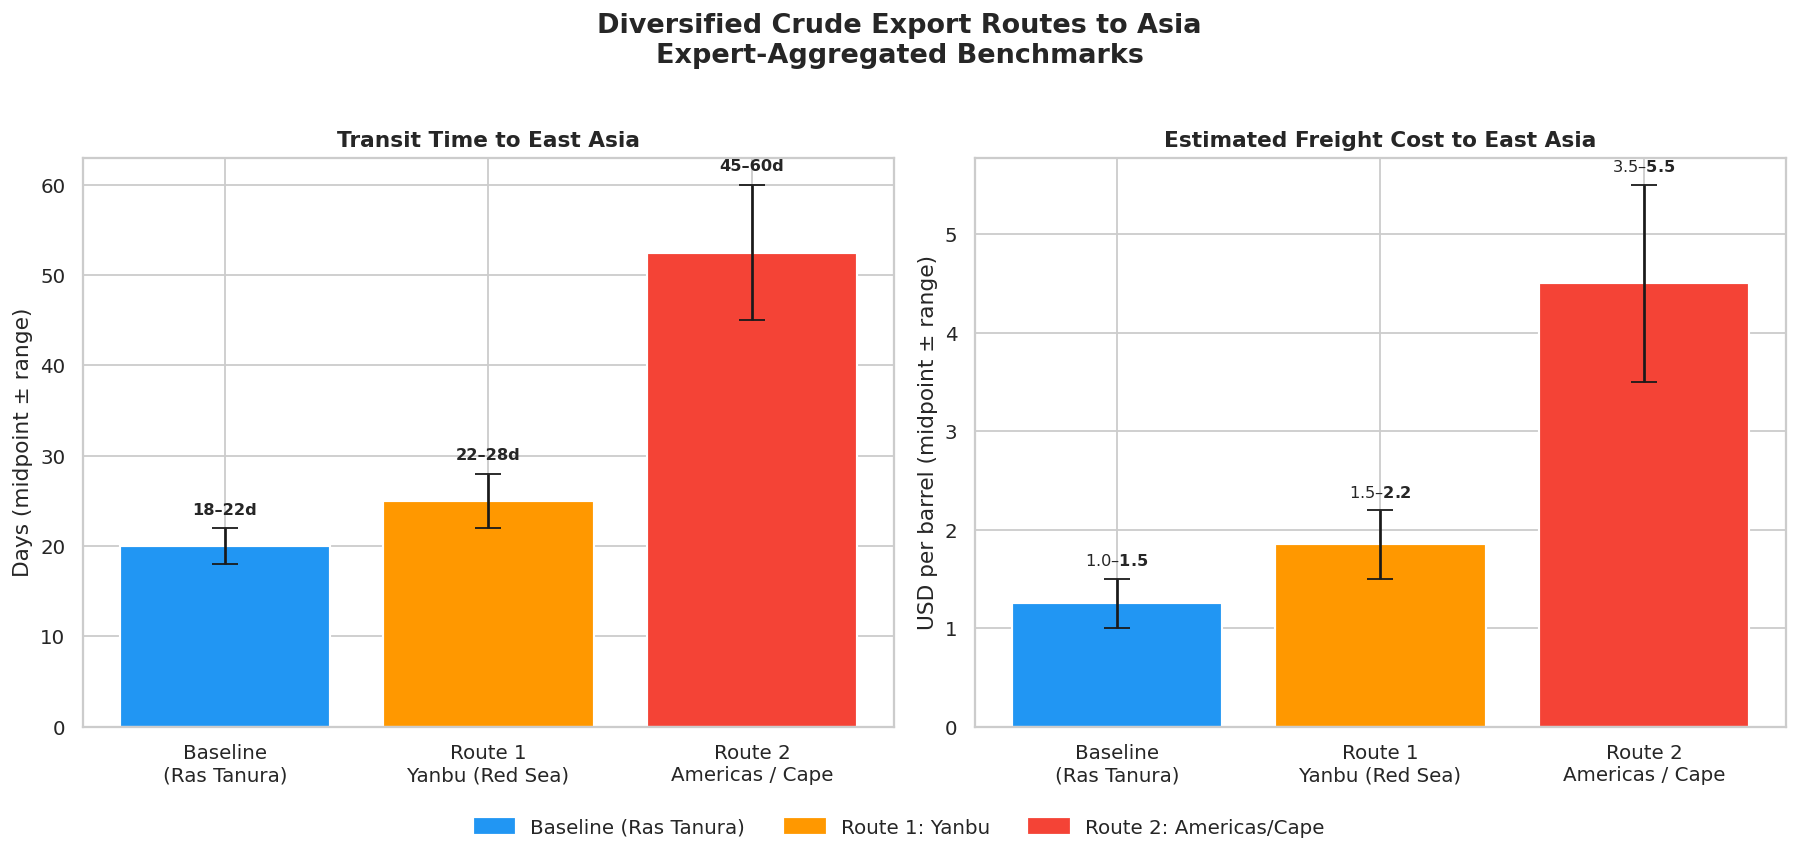

Chart saved as 'crude_route_comparison.png'


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Diversified Crude Export Routes to Asia\nExpert-Aggregated Benchmarks",
             fontsize=15, fontweight="bold", y=1.02)

routes     = ["Baseline\n(Ras Tanura)", "Route 1\nYanbu (Red Sea)", "Route 2\nAmericas / Cape"]
time_mid   = [20, 25, 52.5]   # midpoints of ranges
time_err   = [2, 3, 7.5]
cost_mid   = [1.25, 1.85, 4.5]
cost_err   = [0.25, 0.35, 1.0]
colors     = ["#2196F3", "#FF9800", "#F44336"]


bars0 = axes[0].bar(routes, time_mid, yerr=time_err, color=colors,
                    capsize=7, edgecolor="white", linewidth=1.2)
axes[0].set_title("Transit Time to East Asia", fontweight="bold")
axes[0].set_ylabel("Days (midpoint ± range)")
for bar, val, err in zip(bars0, time_mid, time_err):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + err + 1.2,
                 f"{int(val-err)}–{int(val+err)}d",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")


bars1 = axes[1].bar(routes, cost_mid, yerr=cost_err, color=colors,
                    capsize=7, edgecolor="white", linewidth=1.2)
axes[1].set_title("Estimated Freight Cost to East Asia", fontweight="bold")
axes[1].set_ylabel("USD per barrel (midpoint ± range)")
for bar, val, err in zip(bars1, cost_mid, cost_err):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + err + 0.1,
                 f"${val-err:.1f}–${val+err:.1f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color=colors[0], label="Baseline (Ras Tanura)"),
    mpatches.Patch(color=colors[1], label="Route 1: Yanbu"),
    mpatches.Patch(color=colors[2], label="Route 2: Americas/Cape"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.06), frameon=False)

plt.tight_layout()
plt.savefig("crude_route_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved as 'crude_route_comparison.png'")

In [ ]:
# Save summary table
df_summary.to_csv("../Data_raw/crude_route_summary_table.csv", index=False)

# Save parsed numerical data
if not df_parsed.empty:
    df_parsed.to_csv("../Data_raw/crude_route_parsed_numbers.csv", index=False)

print(" crude_route_summary_table.csv All outputs saved:")
print("   crude_oil_expert_quotes.csv       — full quote database")
print("       — benchmark comparison table")
print("   crude_route_parsed_numbers.csv    — regex-extracted numbers")
print("   crude_route_comparison.png        — bar chart")

 All outputs saved:
   crude_oil_expert_quotes.csv       — full quote database
   crude_route_summary_table.csv     — benchmark comparison table
   crude_route_parsed_numbers.csv    — regex-extracted numbers
   crude_route_comparison.png        — bar chart
